# 8. 프로젝트: 자율주행 보조 시스템 만들기
먼저 주요 라이브러리 버전을 확인해봅시다.

In [1]:
import torch

print(torch.__version__)

2.7.1+cu118


In [70]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 49.1 MB/s eta 0:00:0000:0100:01


In [2]:
!pip install ultralytics 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 8.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 836.9/836.9 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 MB 43.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [ultralytics] [ultralytics]me-32]


[선택된 이미지 경로]: work/object_detection/data/Kitti/raw/testing/image_2/004965.png


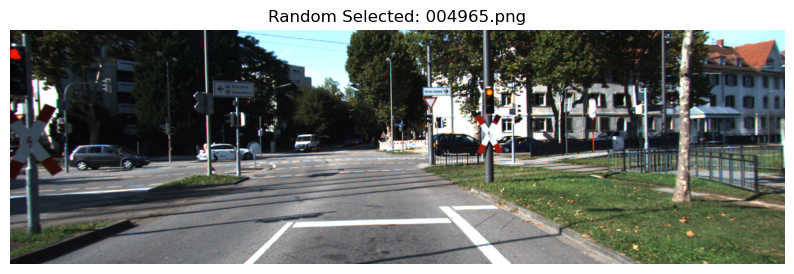

In [3]:
# 학습용 데이터 추출

import os
import random
import shutil
from PIL import Image
import matplotlib.pyplot as plt

# 1. 경로 설정 (사용자 환경에 맞게 절대 경로 또는 상대 경로 확인 필요)
# 원본 데이터 폴더와 목적지 폴더 경로를 정의합니다.
src_dir = "work/object_detection/data/Kitti/raw/testing/image_2"




# 2. 소스 폴더 내의 모든 png 파일 목록 가져오기
png_files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]

if not png_files:
    print(f"오류: '{src_dir}' 폴더 내에 PNG 파일이 존재하지 않습니다.")
else:
    # 3. 랜덤으로 파일 하나 선택
    selected_file = random.choice(png_files)
    src_file_path = os.path.join(src_dir, selected_file)
    
    # 4. 선택된 파일 정보 출력 및 이미지 시각화
    print(f"[선택된 이미지 경로]: {src_file_path}")
    
    img = Image.open(src_file_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')  # 축 숨기기
    plt.title(f"Random Selected: {selected_file}")
    plt.show()
    


In [67]:
# 5. 파일 복사 수행

dst_dir = "work/object_detection/data"
src_dir = "work/object_detection/data/Kitti/raw/testing/image_2"
selected_file = "001134.png"


# 목적지 폴더가 없다면 생성
os.makedirs(dst_dir, exist_ok=True)

dst_file_path = os.path.join(dst_dir, selected_file)
src_file_path = os.path.join(src_dir, selected_file)

try:
    shutil.copy(src_file_path, dst_file_path)
    print(f" 성공적으로 이미지를 복사했습니다!")
    print(f"[저장된 경로]: {dst_file_path}")
except Exception as e:
    print(f"❌ 파일 복사 중 오류가 발생했습니다: {e}")

 성공적으로 이미지를 복사했습니다!
[저장된 경로]: work/object_detection/data/001134.png


## 1️⃣ 자율주행 시스템 만들기
위에서 만든 모델을 통해 아래의 조건을 만족하는 함수를 만들어 주세요.

입력으로 이미지 경로를 받습니다.
정지조건에 맞는 경우 "Stop" 아닌 경우 "Go"를 반환합니다.
조건은 다음과 같습니다.
사람이 한 명 이상 있는 경우
차량의 크기(width or height)가 300px이상인 경우

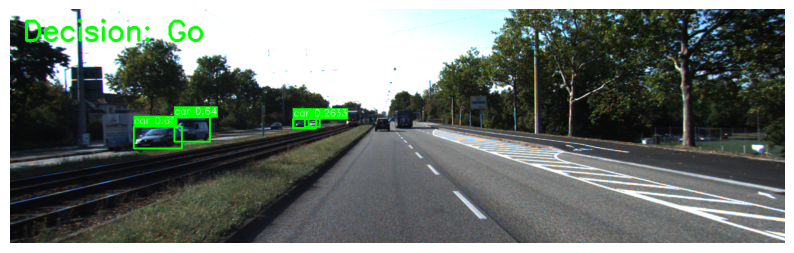

결과: Go


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt # Matplotlib 추가
from ultralytics import YOLO

# YOLOv8 모델 로드
model = YOLO('yolov8n.pt')

def is_red_light(img_crop):
    # (이전과 동일한 헬퍼 함수 코드)
    if img_crop is None or img_crop.size == 0:
        return False
    hsv = cv2.cvtColor(img_crop, cv2.COLOR_BGR2HSV)
    lower_red1, upper_red1 = np.array([0, 70, 50]), np.array([10, 255, 255])
    lower_red2, upper_red2 = np.array([170, 70, 50]), np.array([180, 255, 255])
    mask = cv2.inRange(hsv, lower_red1, upper_red1) + cv2.inRange(hsv, lower_red2, upper_red2)
    return (cv2.countNonZero(mask) / (img_crop.shape[0] * img_crop.shape[1])) > 0.1

def self_drive_assist(img_path, size_limit=300):
    img = cv2.imread(img_path)
    if img is None:
        return "Error: 이미지를 불러올 수 없습니다."

    annotated_img = img.copy()
    results = model(img, verbose=False)
    boxes = results[0].boxes
    decision = "Go"

    for box in boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        w, h = x2 - x1, y2 - y1
        cls_name = model.names[cls_id]
        
        color, stop_reason = (0, 255, 0), ""

        if cls_id == 0:
            decision, stop_reason, color = "Stop", "Pedestrian", (0, 0, 255)
        elif cls_id in [2, 3, 5, 7] and (w >= size_limit or h >= size_limit):
            decision, stop_reason, color = "Stop", "Close Vehicle", (0, 0, 255)
        elif cls_id == 9 and is_red_light(img[y1:y2, x1:x2]):
            decision, stop_reason, color = "Stop", "Red Light", (0, 0, 255)

        label = f"{cls_name} {conf:.2f}" + (f" ({stop_reason})" if stop_reason else "")

        cv2.rectangle(annotated_img, (x1, y1), (x2, y2), color, 2)
        (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(annotated_img, (x1, y1 - text_h - 5), (x1 + text_w, y1), color, -1)
        cv2.putText(annotated_img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    final_color = (0, 0, 255) if decision == "Stop" else (0, 255, 0)
    cv2.putText(annotated_img, f"Decision: {decision}", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, final_color, 3)

    # ---------------------------------------------
    # 💡 여기서부터 수정된 부분입니다! (Matplotlib 출력)
    # ---------------------------------------------
    # 1. BGR 이미지를 RGB로 변환
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    # 2. Matplotlib으로 이미지 출력
    plt.figure(figsize=(10, 8)) # 이미지 크기 조절
    plt.imshow(annotated_img_rgb)
    plt.axis('off') # x축, y축 눈금 숨기기
    plt.show()

    return decision

# 테스트 실행 예시
img_path = 'work/object_detection/data/go_1.png'
print(f"결과: {self_drive_assist(img_path)}")

분석 중인 파일: 000733.png


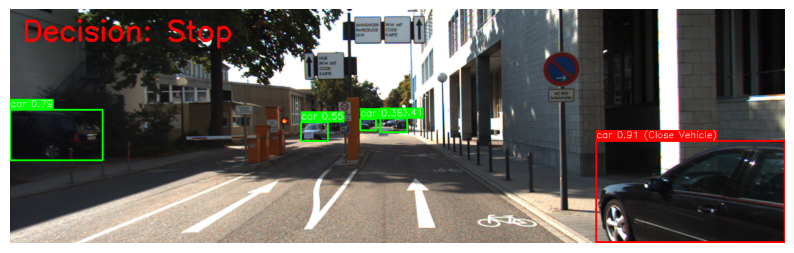

>>> 최종 판단 결과: Stop

분석 중인 파일: 006019.png


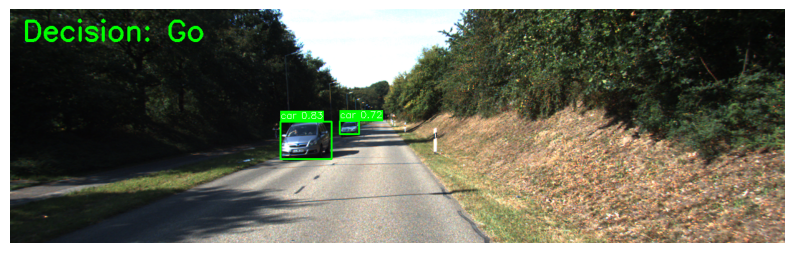

>>> 최종 판단 결과: Go

분석 중인 파일: 006302.png


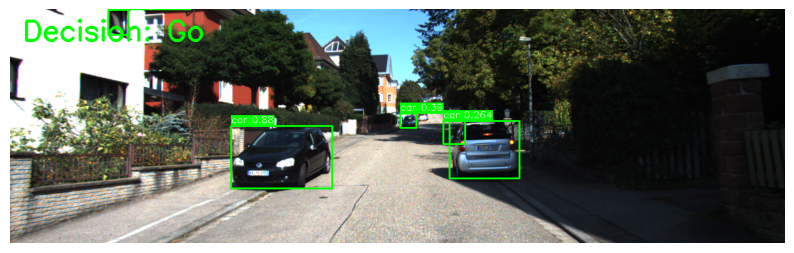

>>> 최종 판단 결과: Go

분석 중인 파일: 006650.png


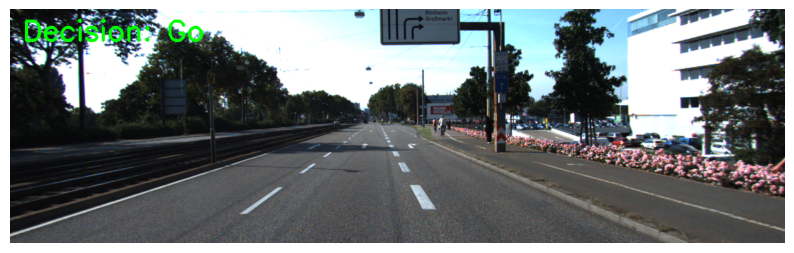

>>> 최종 판단 결과: Go

분석 중인 파일: 006920.png


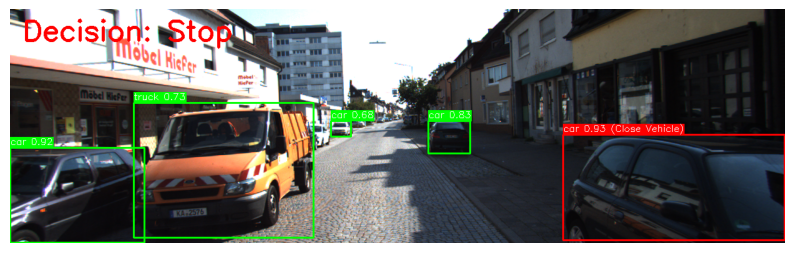

>>> 최종 판단 결과: Stop

분석 중인 파일: go_1.png


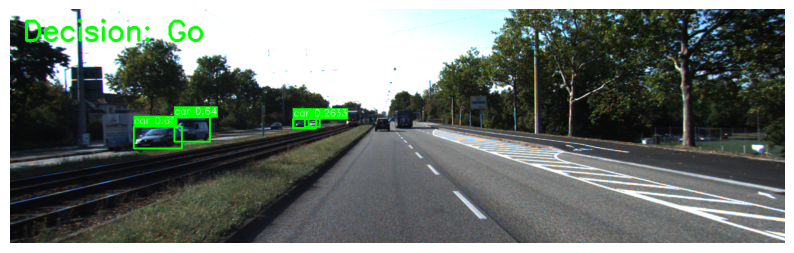

>>> 최종 판단 결과: Go

분석 중인 파일: go_2.png


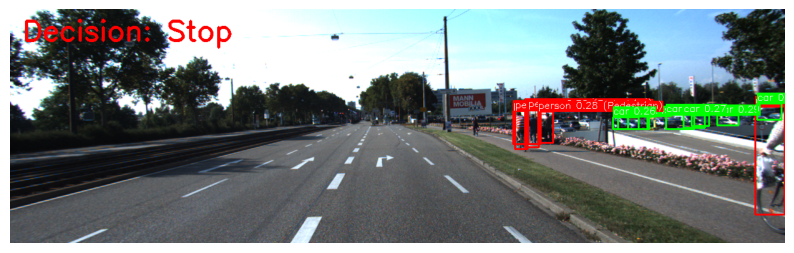

>>> 최종 판단 결과: Stop

분석 중인 파일: go_3.png


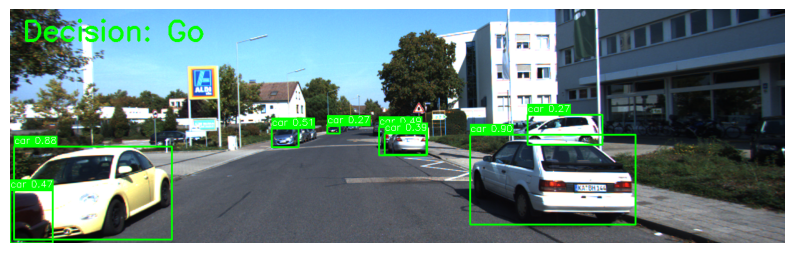

>>> 최종 판단 결과: Go

분석 중인 파일: go_4.png


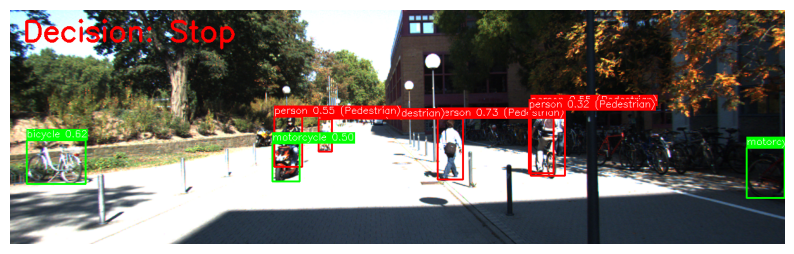

>>> 최종 판단 결과: Stop

분석 중인 파일: go_5.png


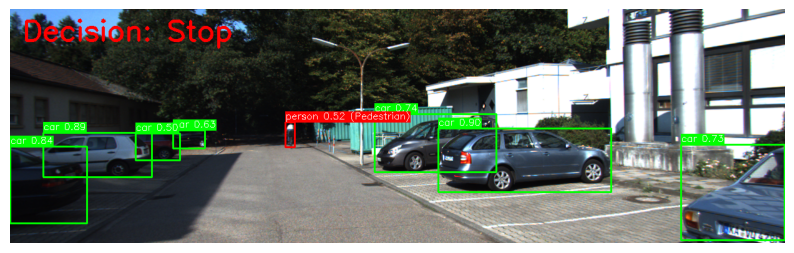

>>> 최종 판단 결과: Stop

분석 중인 파일: stop_1.png


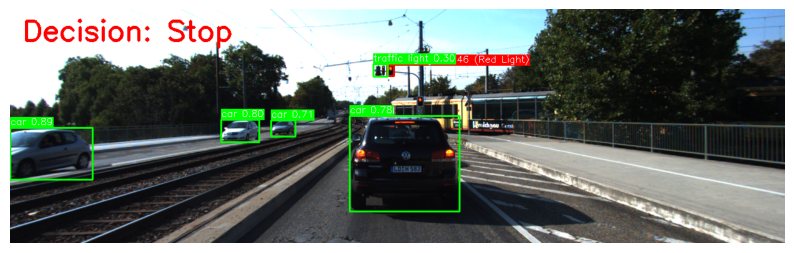

>>> 최종 판단 결과: Stop

분석 중인 파일: stop_2.png


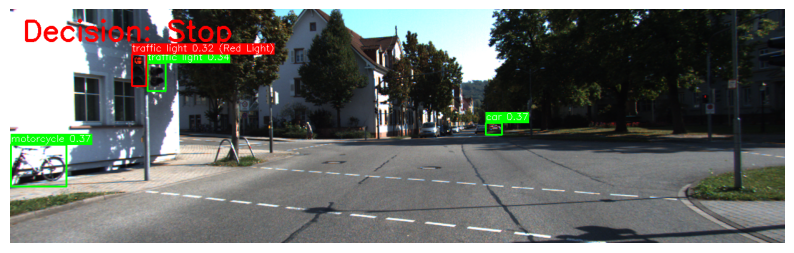

>>> 최종 판단 결과: Stop

분석 중인 파일: stop_3.png


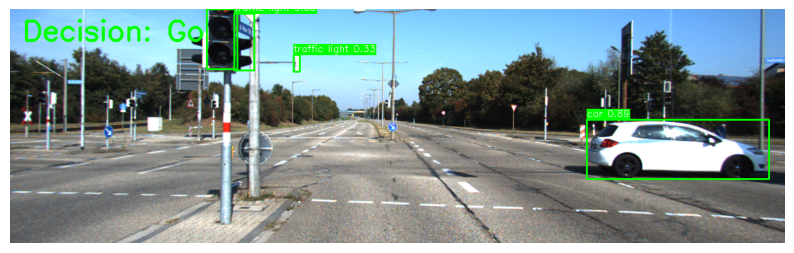

>>> 최종 판단 결과: Go

분석 중인 파일: stop_4.png


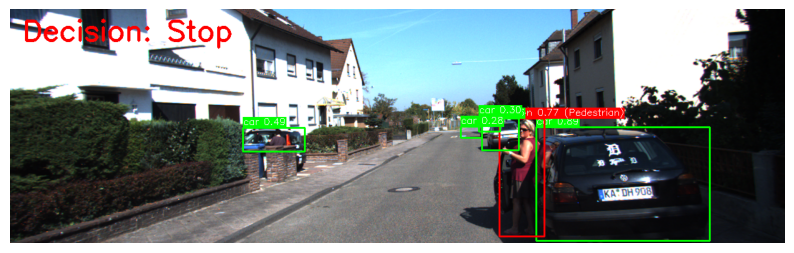

>>> 최종 판단 결과: Stop

분석 중인 파일: stop_5.png


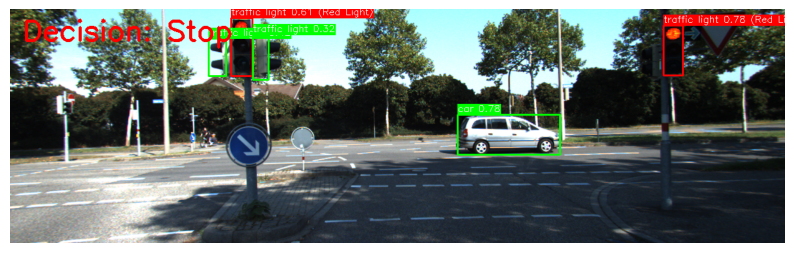

>>> 최종 판단 결과: Stop



In [3]:
import glob
import os

# 1. 이미지가 있는 폴더 경로 지정 (기존 경로 기준)
data_dir = 'work/object_detection/data/'

# 2. 해당 폴더 안의 모든 png 파일 경로를 리스트로 가져오기 (이름순 정렬)
image_paths = sorted(glob.glob(os.path.join(data_dir, '*.png')))

# 3. 파일이 없는 경우를 위한 예외 처리
if not image_paths:
    print(f"'{data_dir}' 경로에 png 파일이 없습니다. 경로를 다시 확인해 주세요.")
else:
    # 4. 반복문을 돌며 모든 이미지에 대해 함수 실행
    for img_path in image_paths:
        file_name = os.path.basename(img_path) # 파일명만 추출 (예: go_1.png)
        print(f"{"="*40}")
        print(f"분석 중인 파일: {file_name}")
        print(f"{"="*40}")
        
        # 앞서 수정한 Matplotlib이 포함된 함수 실행
        result = self_drive_assist(img_path)
        
        print(f">>> 최종 판단 결과: {result}\n")

## 2️⃣ 자율주행 시스템 평가하기
아래 test_system() 를 통해서 위에서 만든 함수를 평가해봅시다. 10장에 대해 Go와 Stop을 맞게 반환하는지 확인하고 100점 만점으로 평가해줍니다.

In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# (is_red_light 헬퍼 함수는 이전과 동일하게 유지)
# ...

# 1. 시각화 여부를 결정하는 visualize 파라미터 추가
def self_drive_assist(img_path, size_limit=300, visualize=False):
    img = cv2.imread(img_path)
    if img is None:
        return "Error: 이미지를 불러올 수 없습니다."

    annotated_img = img.copy()
    results = model(img, verbose=False)
    boxes = results[0].boxes
    decision = "Go"

    for box in boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        w, h = x2 - x1, y2 - y1
        cls_name = model.names[cls_id]
        
        color, stop_reason = (0, 255, 0), ""

        if cls_id == 0:
            decision, stop_reason, color = "Stop", "Pedestrian", (0, 0, 255)
        elif cls_id in [2, 3, 5, 7] and (w >= size_limit or h >= size_limit):
            decision, stop_reason, color = "Stop", "Close Vehicle", (0, 0, 255)
        elif cls_id == 9 and is_red_light(img[y1:y2, x1:x2]):
            decision, stop_reason, color = "Stop", "Red Light", (0, 0, 255)

        # visualize가 True일 때만 박스와 텍스트를 그립니다.
        if visualize:
            label = f"{cls_name} {conf:.2f}" + (f" ({stop_reason})" if stop_reason else "")
            cv2.rectangle(annotated_img, (x1, y1), (x2, y2), color, 2)
            (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(annotated_img, (x1, y1 - text_h - 5), (x1 + text_w, y1), color, -1)
            cv2.putText(annotated_img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # 2. visualize가 True일 때만 이미지를 출력합니다.
    if visualize:
        final_color = (0, 0, 255) if decision == "Stop" else (0, 255, 0)
        cv2.putText(annotated_img, f"Decision: {decision}", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, final_color, 3)
        annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 6))
        plt.imshow(annotated_img_rgb)
        plt.axis('off')
        plt.show()

    return decision

# --- 평가 시스템 ---
def test_system(func):
    work_dir = 'work/object_detection/data'
    score = 0
    test_set = [
        ("stop_1.png", "Stop"), ("stop_2.png", "Stop"), ("stop_3.png", "Stop"),
        ("stop_4.png", "Stop"), ("stop_5.png", "Stop"),
        ("go_1.png", "Go"), ("go_2.png", "Go"), ("go_3.png", "Go"),
        ("go_4.png", "Go"), ("go_5.png", "Go"),
    ]

    print("평가를 시작합니다...")
    for image_file, answer in test_set:
        # os.path.join을 사용하면 운영체제에 맞게 슬래시(/)를 안전하게 처리해줍니다.
        image_path = os.path.join(work_dir, image_file)
        
        # 평가할 때는 시각화하지 않도록 visualize=False 전달 (기본값이 False이므로 생략 가능)
        pred = func(image_path, visualize=False)
        
        if pred == answer:
            score += 10
            print(f"[O] {image_file}: 예측({pred}) == 정답({answer})")
        else:
            print(f"[X] {image_file}: 예측({pred}) != 정답({answer})")
            
    print("-" * 30)
    print(f"최종 점수: {score}점입니다.")

# 테스트 실행!
test_system(self_drive_assist)

평가를 시작합니다...
[O] stop_1.png: 예측(Stop) == 정답(Stop)
[O] stop_2.png: 예측(Stop) == 정답(Stop)
[X] stop_3.png: 예측(Go) != 정답(Stop)
[O] stop_4.png: 예측(Stop) == 정답(Stop)
[O] stop_5.png: 예측(Stop) == 정답(Stop)
[O] go_1.png: 예측(Go) == 정답(Go)
[X] go_2.png: 예측(Stop) != 정답(Go)
[O] go_3.png: 예측(Go) == 정답(Go)
[X] go_4.png: 예측(Stop) != 정답(Go)
[X] go_5.png: 예측(Stop) != 정답(Go)
------------------------------
최종 점수: 60점입니다.
